In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C

Function 4: Fast, but Inaccurate Modelling

This example is for a particular business relying heavily on online sales. It can run very accurate calculations to figure out what is the optimal placement of their product across warehouses. Unfortunately, the calculations are extremely expensive (computationally) to run, so they can only do it once every two weeks. Instead, they propose using a machine learning model which approximates the solution quickly (in a few hours). The model has four hyper-parameters you need to tune, and the output corresponds to the difference between the expensive calculation, and the model. Since you are modelling a dynamical system, expect a lot of local optima!

**Problem Overview**

**Scenario**
- A business relies on online sales and needs to decide how to optimally place products across multiple warehouses.
- There is a very accurate simulation (the "expensive calculation") that can tell you the best placement, but it takes a long time to run (e.g., two weeks per run).
- To make decisions more quickly, the business uses a machine learning model that can approximate the optimal placement in just a few hours.

**Our Task**
- The machine learning model has four hyperparameters that you can tune.
- The output you observe is the difference (error) between the expensive calculation and the model’s prediction for a given set of hyperparameters.
- Our goal is to minimize this difference—that is, find the hyperparameter settings that make the model as close as possible to the expensive, accurate calculation.

**Challenges**
- **Many Local Optima:** The system is "dynamical," meaning the error surface (difference between model and true calculation) is bumpy, with many peaks and valleys. It’s easy to get stuck in a suboptimal solution.
- **Expensive Evaluations:** You can’t afford to run the expensive calculation often, so you must rely on the fast model and optimize its hyperparameters efficiently.

**Real-World Analogy**
Imagine we’re tuning a racing car’s settings (the four hyperparameters) to match the performance of a world champion’s car (the expensive calculation).

- Testing our car on the real track (expensive calculation) is costly and slow.
- We use a simulator (machine learning model) to try different settings quickly.
- Our goal is to adjust the simulator’s settings so its lap times are as close as possible to the real champion’s times.

**Goal**
Our goal is to minimize the loss i.e the difference between true value and predicted value i.e. expensive calculation and the model’s prediction respectively.

In [2]:
def queries_for_function(number):
    if number < 1 or number > 8:
        return []
        
    with open('../queries.txt', 'r') as file:  # Fixed the path separator for cross-platform compatibility
        file_content = file.read()
        
    all_queries = file_content.split('])]')
    
    formatted_queries = [query.replace('\n', '') + '])]' for query in all_queries if query]
    
    actual_queries = []
    for query in formatted_queries:
        formatted_query = query.replace('array(', '').replace(')', '').strip()
        
        try:
            query_formatted_as_list = eval(formatted_query)  # Ensure eval is safe or replace with a safer alternative
            query_as_2d_array = np.array(query_formatted_as_list, dtype=object)
            actual_queries.append(query_as_2d_array[number - 1])
        except (SyntaxError, IndexError, ValueError) as e:
            print(f"Warning: Skipping query due to error - {e}")
            continue

    return actual_queries


def observations_for_function(number):
    if number < 1 or number > 8:
        return []
    
    data = []
    
    with open('../observations.txt', 'r') as file:  # Fixed the path separator for cross-platform compatibility
        for line in file:
            try:
                # Extract the float values from the line
                values = [float(value.split('(')[1].split(')')[0]) for value in line.strip().split(', ')]
                data.append(values)
            except (IndexError, ValueError) as e:
                print(f"Warning: Skipping line due to error - {e}")
                continue
            
    # Convert the list of lists into a numpy array
    data_array = np.array(data)
    
    # Extract each column as a numpy array
    columns = [data_array[:, i] for i in range(data_array.shape[1])] if data_array.size > 0 else []
    
    return columns[number - 1] if number - 1 < len(columns) else []

In [3]:
X = np.load("initial_inputs.npy")
X, len(X)

(array([[0.89698105, 0.72562797, 0.17540431, 0.70169437],
        [0.8893564 , 0.49958786, 0.53926886, 0.50878344],
        [0.25094624, 0.03369313, 0.14538002, 0.49493242],
        [0.34696206, 0.0062504 , 0.76056361, 0.61302356],
        [0.12487118, 0.12977019, 0.38440048, 0.2870761 ],
        [0.80130271, 0.50023109, 0.70664456, 0.19510284],
        [0.24770826, 0.06044543, 0.04218635, 0.44132425],
        [0.74670224, 0.7570915 , 0.36935306, 0.20656628],
        [0.40066503, 0.07257425, 0.88676825, 0.24384229],
        [0.6260706 , 0.58675126, 0.43880578, 0.77885769],
        [0.95713529, 0.59764438, 0.76611385, 0.77620991],
        [0.73281243, 0.14524998, 0.47681272, 0.13336573],
        [0.65511548, 0.07239183, 0.68715175, 0.08151656],
        [0.21973443, 0.83203134, 0.48286416, 0.08256923],
        [0.48859419, 0.2119651 , 0.93917791, 0.37619173],
        [0.16713049, 0.87655456, 0.21723954, 0.95980098],
        [0.21691119, 0.16608583, 0.24137226, 0.77006248],
        [0.387

In [4]:
queries = queries_for_function(4)
X = np.vstack([X, queries])
X, len(X)

(array([[8.96981054e-01, 7.25627970e-01, 1.75404309e-01, 7.01694369e-01],
        [8.89356396e-01, 4.99587855e-01, 5.39268858e-01, 5.08783439e-01],
        [2.50946243e-01, 3.36931305e-02, 1.45380025e-01, 4.94932421e-01],
        [3.46962061e-01, 6.25040024e-03, 7.60563606e-01, 6.13023557e-01],
        [1.24871181e-01, 1.29770193e-01, 3.84400483e-01, 2.87076101e-01],
        [8.01302707e-01, 5.00231094e-01, 7.06644560e-01, 1.95102841e-01],
        [2.47708262e-01, 6.04454273e-02, 4.21863451e-02, 4.41324251e-01],
        [7.46702242e-01, 7.57091504e-01, 3.69353060e-01, 2.06566281e-01],
        [4.00665027e-01, 7.25742511e-02, 8.86768254e-01, 2.43842290e-01],
        [6.26070596e-01, 5.86751259e-01, 4.38805782e-01, 7.78857694e-01],
        [9.57135293e-01, 5.97644383e-01, 7.66113852e-01, 7.76209905e-01],
        [7.32812426e-01, 1.45249979e-01, 4.76812718e-01, 1.33365734e-01],
        [6.55115479e-01, 7.23918269e-02, 6.87151746e-01, 8.15165642e-02],
        [2.19734429e-01, 8.32031335e-0

In [5]:
y = np.load("initial_outputs.npy")
y, len(y)

(array([-22.10828779, -14.60139663, -11.69993246, -16.05376511,
        -10.06963343, -15.48708254, -12.68168498, -16.02639977,
        -17.04923465, -12.74176599, -27.31639636, -13.52764887,
        -16.6791152 , -16.50715856, -17.81799934, -26.56182083,
        -12.75832422, -19.44155762, -28.90327367, -13.70274694,
        -29.4270914 , -11.56574199, -26.85778644,  -7.96677535,
         -6.70208925, -32.62566022, -19.98949793,  -4.02554228,
        -13.12278233, -23.1394284 ]),
 30)

In [6]:
observations = observations_for_function(4)
for observation in observations:
    y = np.append(y, [observation], axis=0)
y, len(y)

(array([-2.21082878e+01, -1.46013966e+01, -1.16999325e+01, -1.60537651e+01,
        -1.00696334e+01, -1.54870825e+01, -1.26816850e+01, -1.60263998e+01,
        -1.70492346e+01, -1.27417660e+01, -2.73163964e+01, -1.35276489e+01,
        -1.66791152e+01, -1.65071586e+01, -1.78179993e+01, -2.65618208e+01,
        -1.27583242e+01, -1.94415576e+01, -2.89032737e+01, -1.37027469e+01,
        -2.94270914e+01, -1.15657420e+01, -2.68577864e+01, -7.96677535e+00,
        -6.70208925e+00, -3.26256602e+01, -1.99894979e+01, -4.02554228e+00,
        -1.31227823e+01, -2.31394284e+01, -3.64577364e+01, -3.53040575e+01,
        -4.80001750e+01, -2.77906953e+01, -2.77999478e+01, -2.55976685e+01,
        -1.36309811e+01, -1.54029766e+01, -1.04482527e+01, -2.55976685e+01,
        -3.53040575e+01, -3.53040575e+01, -4.80001750e+01, -2.31763355e-02,
         4.81211135e-01, -3.57480990e-01,  5.75744656e-01]),
 47)

In [7]:
def best_observation(y):
    best_idx = np.argmax(y)
    best_observation_so_far = y[best_idx]
    best_query_so_far = X[best_idx]
    print("Best observation so far:", best_observation_so_far)
    print("Best query so far:", best_query_so_far)
    return best_observation_so_far, best_query_so_far

best_observation_so_far, best_query_so_far = best_observation(y)

Best observation so far: 0.5757446557048209
Best query so far: [0.412421 0.431277 0.400389 0.417171]


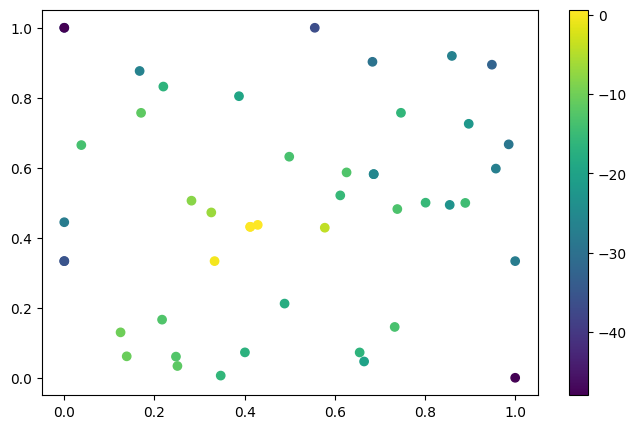

In [8]:
fig, ax = plt.subplots()
fig.set_figheight(5)
fig.set_figwidth(8)
plt.scatter(X[:, 0], X[:, 1], c = y)
plt.colorbar()

Text(0.5, 0.92, 'Scatter Plot of Contamination Sources Input Data Points with Output Variable y')

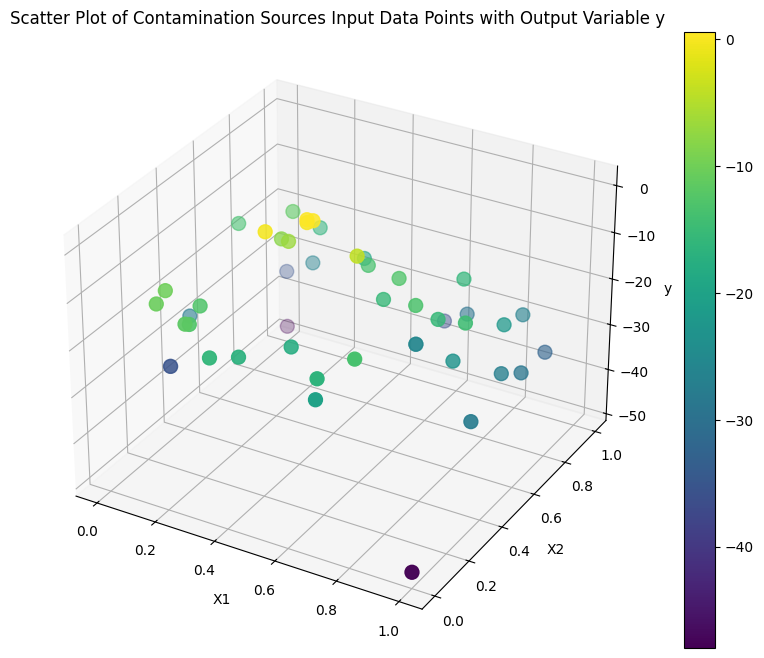

In [9]:
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
sc = ax.scatter(X[:,0], X[:,1], y, c=y, cmap='viridis', s=100)

plt.colorbar(sc)
ax.set_xlabel('X1')
ax.set_ylabel('X2')
ax.set_zlabel('y')

ax.set_title('Scatter Plot of Contamination Sources Input Data Points with Output Variable y')


**Acquisition Functions**

In [10]:
#UCB is useful when you want a balance between exploring new areas of the search space (high uncertainty) and exploiting known areas 
#with high mean values. The parameter β controls this balance. It's a good general-purpose acquisition function for many optimization problems.
def upper_confidence_bound(post_mean, post_std, beta):
    ucb = post_mean + beta * post_std # upper confidence bpon (ucb) = mu + kappa * sigma 
    print("\n\nUCB Shape: ", np.shape(ucb))
    return ucb


#PI is more focused on exploitation, as it prioritizes areas where the predicted mean is higher than the current best observed value (ymax)
#Use PI when you have a well-calibrated model and you want to focus on improving the best observed value.
def probability_of_improvement(post_mean, post_std, y_max):
    # Calculate the improvement
    improvement = post_mean - y_max
    
    # Calculate the Z value
    Z = improvement / post_std
    
    # Calculate the probability of improvement using the cumulative distribution function (CDF) of the normal distribution
    PI = norm.cdf(Z)
    print("\n\nPI Shape: ", np.shape(PI))
    return PI


def probability_of_improvement_with_exploration_term(post_mean, post_std, y_max, epsilon):
    # Calculate the improvement with exploration term
    improvement = post_mean - (y_max + epsilon)
    
    # Calculate the Z value
    Z = improvement / post_std
    
    # Calculate the probability of improvement using the cumulative distribution function (CDF) of the normal distribution
    PI = norm.cdf(Z)
    print("\n\nPI With Exploitation Term Shape: ", np.shape(PI))
    return PI


#EI provides a balance between exploration and exploitation, similar to UCB, but it also considers the magnitude of improvement.
#Use EI when you want to maximize the expected improvement over the current best observed value.
def expected_improvement(post_mean, post_std, y_max):
    # Calculate the improvement
    improvement = post_mean - y_max
    
    # Calculate the Z value
    Z = improvement / post_std
    
    # Calculate the expected improvement
    EI = improvement * norm.cdf(Z) + post_std * norm.pdf(Z)
    print("\n\nEI Shape: ", np.shape(EI))
    return EI

#Thompson Sampling is useful when you want to sample from the posterior distribution of the model, which inherently balances exploration and exploitation.
#Use Thompson Sampling when you want a stochastic approach to selecting the next point.
def thompson_sampling(post_mean, post_std):
    # Sample from the posterior distribution
    samples = np.random.normal(post_mean, post_std)
    print("\n\nThompson Samples Shape: ", np.shape(samples))
    return samples

**Input Sampling Methods**

In [11]:
def exploration_grid():
    x1_grid = np.linspace(0.000001, 0.999999, 10)
    x2_grid = np.linspace(0.000001, 0.999999, 10)
    x3_grid = np.linspace(0.000001, 0.999999, 10)
    x4_grid = np.linspace(0.000001, 0.999999, 10)

    x1_grid, x2_grid, x3_grid, x4_grid = np.meshgrid(x1_grid, x2_grid, x3_grid, x4_grid)    
    x_grid = np.vstack([x1_grid.ravel(), x2_grid.ravel(), x3_grid.ravel(),  x4_grid.ravel()]).T

    return x_grid

def exploitation_grid(center, delta=0.05):
    """
    Create a grid for exploitation around the given center point (array of 4 values).
    delta: half-width of the interval to explore around each coordinate.
    """
    x1, x2, x3, x4 = center
    x1_grid = np.linspace(max(0.000001, x1 - delta), min(0.999999, x1 + delta), 10)
    x2_grid = np.linspace(max(0.000001, x2 - delta), min(0.999999, x2 + delta), 10)
    x3_grid = np.linspace(max(0.000001, x3 - delta), min(0.999999, x3 + delta), 10)
    x4_grid = np.linspace(max(0.000001, x4 - delta), min(0.999999, x4 + delta), 10)

    x1_grid, x2_grid, x3_grid, x4_grid = np.meshgrid(x1_grid, x2_grid, x3_grid, x4_grid)    
    x_grid = np.vstack([x1_grid.ravel(), x2_grid.ravel(), x3_grid.ravel(), x4_grid.ravel()]).T

    return x_grid

def exploration_latin_hypercube():
    """
    Create a Latin Hypercube sample for exploration.
    """
    from scipy.stats import qmc
    n_samples = 10000
    bounds = [
        (0.000001, 0.999999),  # x1
        (0.000001, 0.999999),  # x2
        (0.000001, 0.999999),  # x3
        (0.000001, 0.999999)   # x4
    ]
    sampler = qmc.LatinHypercube(d=4)
    lhs_sample = sampler.random(n=n_samples)
    l_bounds = np.array([b[0] for b in bounds])
    u_bounds = np.array([b[1] for b in bounds])
    lhs_samples = qmc.scale(lhs_sample, l_bounds, u_bounds)
    return lhs_samples

def exploitation_latin_hypercube(center, delta=0.05):
    """
    Create a Latin Hypercube sample for exploitation around the given center point (array of 4 values).
    delta: half-width of the interval to explore around each coordinate.
    """
    from scipy.stats import qmc
    n_samples = 10000
    bounds = [
        (max(0.000001, center[0] - delta), min(0.999999, center[0] + delta)),  # x1
        (max(0.000001, center[1] - delta), min(0.999999, center[1] + delta)),  # x2
        (max(0.000001, center[2] - delta), min(0.999999, center[2] + delta)),  # x3
        (max(0.000001, center[3] - delta), min(0.999999, center[3] + delta))   # x4
    ]
    sampler = qmc.LatinHypercube(d=4)
    lhs_sample = sampler.random(n=n_samples)
    l_bounds = np.array([b[0] for b in bounds])
    u_bounds = np.array([b[1] for b in bounds])
    lhs_samples = qmc.scale(lhs_sample, l_bounds, u_bounds)
    return lhs_samples

In [12]:
def query_black_box_function_with_default_kernel(X, y, x_grid, acquisition_func):
    
    beta = 1.96
    model = GaussianProcessRegressor()
    model.fit(X, y)
       
    post_mean, post_std = model.predict(x_grid, return_std=True) #post_mean is y_pred and post_std is sigma i.e. s
    #acquisition_function = post_mean + beta * post_std # upper confidence bound (ucb) = mu + kappa * sigma mu + kappa * sigma 
    if acquisition_func == upper_confidence_bound:
        acquisition_function = acquisition_func(post_mean, post_std, beta)
        
    elif acquisition_func == probability_of_improvement:
        y_max = np.max(y)  # Define y_max as the maximum observed value
        acquisition_function = acquisition_func(post_mean, post_std, y_max)
        
    elif acquisition_func == probability_of_improvement_with_exploration_term:
        y_max = np.max(y)
        acquisition_function = acquisition_func(post_mean, post_std, y_max, 0.8)

    elif acquisition_func == expected_improvement:
        y_max = np.max(y)
        acquisition_function = acquisition_func(post_mean, post_std, y_max)

    else: #thompson_sampling
         acquisition_function = acquisition_func(post_mean, post_std)
    
    next_query = x_grid[np.argmax(acquisition_function)]
    y_pred = post_mean[np.argmax(acquisition_function)]
    
    next_query = next_query.reshape(1,4)
    y_pred = np.array([y_pred])
    
    print(f"Query to Black Box Function Maximizes at Input: ({next_query[0][0]:.6f}-{next_query[0][1]:.6f}-{next_query[0][2]:.6f}-{next_query[0][3]:.6f})")
    print(f"Predicted Value at ({next_query[0][0]:.6f}-{next_query[0][1]:.6f}-{next_query[0][2]:.6f}-{next_query[0][3]:.6f}) is {y_pred[0]})") 
    print("Index of maximum acquisition function value: ", np.argmax(acquisition_function))
   
    return next_query, y_pred

In [13]:
def next_query_with_default_kernel(X, y, x_grid):
    x_random = np.random.uniform(size = 2)
    print(f"Random Query: {x_random[0]:.6f}-{x_random[1]:.6f}")

    x_ucb, y_pred_ucb = query_black_box_function_with_default_kernel(X, y, x_grid, upper_confidence_bound)
    
    x_pi, y_pred_pi = query_black_box_function_with_default_kernel(X, y, x_grid, probability_of_improvement)
    
    x_piet, y_pred_piet = query_black_box_function_with_default_kernel(X, y, x_grid, probability_of_improvement_with_exploration_term)
    
    x_ei, y_pred_ei = query_black_box_function_with_default_kernel(X, y, x_grid, expected_improvement)
    
    x_ts, y_pred_ts = query_black_box_function_with_default_kernel(X, y, x_grid, thompson_sampling)

    return x_ucb, y_pred_ucb, x_pi, y_pred_pi, x_piet, y_pred_piet, x_ei, y_pred_ei, x_ts, y_pred_ts

**Exploration**

Explore the whole space with **defalut** RBF Kernel

In [14]:
x_ucb, y_pred_ucb, x_pi, y_pred_pi, x_piet, y_pred_piet, x_ei, y_pred_ei, x_ts, y_pred_ts = next_query_with_default_kernel(X, y, exploration_grid())

Random Query: 0.729695-0.827593


UCB Shape:  (10000,)
Query to Black Box Function Maximizes at Input: (0.444445-0.444445-0.444445-0.444445)
Predicted Value at (0.444445-0.444445-0.444445-0.444445) is 0.40793679768103175)
Index of maximum acquisition function value:  4444


PI Shape:  (10000,)
Query to Black Box Function Maximizes at Input: (0.000001-0.000001-0.000001-0.000001)
Predicted Value at (0.000001-0.000001-0.000001-0.000001) is -20.40172356320545)
Index of maximum acquisition function value:  0


PI With Exploitation Term Shape:  (10000,)
Query to Black Box Function Maximizes at Input: (0.000001-0.000001-0.000001-0.000001)
Predicted Value at (0.000001-0.000001-0.000001-0.000001) is -20.40172356320545)
Index of maximum acquisition function value:  0


EI Shape:  (10000,)
Query to Black Box Function Maximizes at Input: (0.000001-0.000001-0.000001-0.000001)
Predicted Value at (0.000001-0.000001-0.000001-0.000001) is -20.40172356320545)
Index of maximum acquisition function value:

**Exploitation**

In [15]:
best_observation_so_far, best_query_so_far = best_observation(y)

Best observation so far: 0.5757446557048209
Best query so far: [0.412421 0.431277 0.400389 0.417171]


In [16]:
x_ucb, y_pred_ucb, x_pi, y_pred_pi, x_piet, y_pred_piet, x_ei, y_pred_ei, x_ts, y_pred_ts = next_query_with_default_kernel(X, y, exploitation_grid(best_query_so_far))

Random Query: 0.344321-0.566229


UCB Shape:  (10000,)
Query to Black Box Function Maximizes at Input: (0.406865-0.392388-0.417056-0.456060)
Predicted Value at (0.406865-0.392388-0.417056-0.456060) is 0.751105200179154)
Index of maximum acquisition function value:  1468


PI Shape:  (10000,)
Query to Black Box Function Maximizes at Input: (0.362421-0.381277-0.417056-0.456060)
Predicted Value at (0.362421-0.381277-0.417056-0.456060) is 0.5950888246588875)
Index of maximum acquisition function value:  68


PI With Exploitation Term Shape:  (10000,)
Query to Black Box Function Maximizes at Input: (0.362421-0.381277-0.350389-0.367171)
Predicted Value at (0.362421-0.381277-0.350389-0.367171) is -0.1990002392558381)
Index of maximum acquisition function value:  0


EI Shape:  (10000,)
Query to Black Box Function Maximizes at Input: (0.406865-0.392388-0.417056-0.456060)
Predicted Value at (0.406865-0.392388-0.417056-0.456060) is 0.751105200179154)
Index of maximum acquisition function value: 

**Hyperparameter Tuning using gp_minimize**

In [17]:
from sklearn.gaussian_process.kernels import Matern, RationalQuadratic, DotProduct
def query_black_box_function_with_hyper_parameters(X, y, x_grid, acquisition_func, kernel_type, rbf_lengthscale, noise_assumption, restarts, beta):
    # Define the kernel based on the kernel_type parameter
    if kernel_type == 'RBF':
        kernel = RBF(length_scale=rbf_lengthscale, length_scale_bounds=(1e-2, 1e2)) * C(1.0, (1e-5, 1e5))

    elif kernel_type == 'Matern':
        kernel = Matern(length_scale=rbf_lengthscale, length_scale_bounds=(1e-2, 1e2), nu=1.5)

    elif kernel_type == 'RationalQuadratic':
        kernel = RationalQuadratic(length_scale=rbf_lengthscale, alpha=1.0) * C(1.0, (1e-5, 1e5))
      
    elif kernel_type == 'DotProduct':
        kernel = DotProduct(sigma_0=1.0, sigma_0_bounds=(1e-3, 1e3)) + C(1.0, (1e-5, 1e5))
    else:
        kernel = None

    # Create and fit the Gaussian Process model
    if kernel is None:
        model = GaussianProcessRegressor()
    else:   
        model = GaussianProcessRegressor(kernel=kernel, alpha=noise_assumption, n_restarts_optimizer=restarts)

    model.fit(X, y)

    # Predict the mean and standard deviation
    post_mean, post_std = model.predict(x_grid, return_std=True)

    # Compute the acquisition function
    if acquisition_func == upper_confidence_bound:
        acquisition_function = acquisition_func(post_mean, post_std, beta)
    elif acquisition_func == probability_of_improvement:
        y_max = np.max(y)
        acquisition_function = acquisition_func(post_mean, post_std, y_max)
    elif acquisition_func == probability_of_improvement_with_exploration_term:
        y_max = np.max(y)
        acquisition_function = acquisition_func(post_mean, post_std, y_max, 0.8)
    elif acquisition_func == expected_improvement:
        y_max = np.max(y)
        acquisition_function = acquisition_func(post_mean, post_std, y_max)
    else:  # thompson_sampling
        acquisition_function = acquisition_func(post_mean, post_std)

    # Find the point that maximizes the acquisition function
    next_query = x_grid[np.argmax(acquisition_function)]
    y_pred = post_mean[np.argmax(acquisition_function)]

    next_query = next_query.reshape(1, 4)
    y_pred = np.array([y_pred])

    print(f"Query to Black Box Function Maximizes at Input: ({next_query[0][0]:.6f}-{next_query[0][1]:.6f}-{next_query[0][2]:.6f}-{next_query[0][3]:.6f})")
    print(f"Predicted Value at ({next_query[0][0]:.6f}-{next_query[0][1]:.6f}-{next_query[0][2]:.6f}-{next_query[0][3]:.6f}) is {y_pred[0]})") 
    print("Index of maximum acquisition function value: ", np.argmax(acquisition_function))
    print("Kernel type: ", kernel_type)

    return next_query, y_pred

**Hyperparameter Tuning using gp_minimize**

With Full Grid as Search Space

In [18]:
# Install scikit-optimize if not already installed
%pip install scikit-optimize

from skopt import gp_minimize
from skopt.space import Real, Integer, Categorical
from skopt.utils import use_named_args

x_grid = exploration_grid()


# Define the search space
search_space = [
    Real(0.01, 1.0, name='lengthscale'),
    Real(1e-10, 1e-1, name='noise_assumption'),
    Integer(0, 15, name='restarts'),
    Real(1.0, 3.0, name='beta'),
    Categorical([upper_confidence_bound, probability_of_improvement, 
                 probability_of_improvement_with_exploration_term, 
                 expected_improvement, thompson_sampling], name='acquisition_func'),
    Categorical(['RBF', 'Matern', 'RationalQuadratic', 'DotProduct'], name='kernel_type')
]

# Define the objective function
@use_named_args(search_space)
def objective_function_gp(lengthscale, noise_assumption, restarts, beta, acquisition_func, kernel_type):
    global best_x_ucb, best_y_pred_ucb, best_params

    next_query, y_pred = query_black_box_function_with_hyper_parameters(
        X, y, x_grid,
        acquisition_func=acquisition_func,
        kernel_type=kernel_type,
        rbf_lengthscale=lengthscale,
        noise_assumption=noise_assumption,
        restarts=restarts,
        beta=beta
    )
    
    # Return the negative of the prediction as we want to maximize y_pred_ucb
    return -y_pred[0]

# Perform Bayesian optimization
result = gp_minimize(
    func=objective_function_gp,
    dimensions=search_space,
    n_calls=50,  # Number of evaluations
    random_state=42
)

# Extract the best parameters
(best_rbf_lengthscale, best_noise_assumption, best_restarts, 
 best_beta, best_acquisition_func, best_kernel_type) = result.x
print(f"Best Parameters: rbf_lengthscale={best_rbf_lengthscale}, noise_assumption={best_noise_assumption}, "
      f"restarts={best_restarts}, beta={best_beta}, acquisition_func={best_acquisition_func.__name__}, "
      f"kernel_type={best_kernel_type}")

# Use the best parameters to query the black-box function
next_query, y_pred = query_black_box_function_with_hyper_parameters(
    X, y, x_grid,
    acquisition_func=best_acquisition_func,
    kernel_type=best_kernel_type,
    rbf_lengthscale=best_rbf_lengthscale, 
    noise_assumption=best_noise_assumption,
    restarts=best_restarts,
    beta=best_beta
)

next_query, y_pred


[notice] A new release of pip is available: 25.0.1 -> 25.1.1
[notice] To update, run: C:\Users\harji\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


PI With Exploitation Term Shape:  (10000,)
Query to Black Box Function Maximizes at Input: (0.333334-0.444445-0.444445-0.444445)
Predicted Value at (0.333334-0.444445-0.444445-0.444445) is 0.3074176125410304)
Index of maximum acquisition function value:  4344
Kernel type:  RBF


UCB Shape:  (10000,)
Query to Black Box Function Maximizes at Input: (0.333334-0.444445-0.444445-0.444445)
Predicted Value at (0.333334-0.444445-0.444445-0.444445) is 0.2771155170776183)
Index of maximum acquisition function value:  4344
Kernel type:  RationalQuadratic


EI Shape:  (10000,)
Query to Black Box Function Maximizes at Input: (0.333334-0.444445-0.444445-0.444445)
Predicted Value at (0.333334-0.444445-0.444445-0.444445) is 0.28890241281987983)
Index of maximum acquisition function value:  4344
Kernel type:  RBF


Thompson Samples Shape:  (10000,)
Query to B

C:\Users\harji\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\gaussian_process\kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__sigma_0 is close to the specified lower bound 0.001. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(




UCB Shape:  (10000,)
Query to Black Box Function Maximizes at Input: (0.000001-0.000001-0.000001-0.000001)
Predicted Value at (0.000001-0.000001-0.000001-0.000001) is 3.3760945051908493)
Index of maximum acquisition function value:  0
Kernel type:  DotProduct


C:\Users\harji\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\gaussian_process\_gpr.py:660: ConvergenceWarning: lbfgs failed to converge (status=2):
ABNORMAL: .

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  _check_optimize_result("lbfgs", opt_res)


...



PI Shape:  (10000,)
Query to Black Box Function Maximizes at Input: (0.000001-0.000001-0.000001-0.000001)
Predicted Value at (0.000001-0.000001-0.000001-0.000001) is 3.421875)
Index of maximum acquisition function value:  0
Kernel type:  DotProduct


EI Shape:  (10000,)
Query to Black Box Function Maximizes at Input: (0.000001-0.000001-0.000001-0.000001)
Predicted Value at (0.000001-0.000001-0.000001-0.000001) is 2.930963342175801)
Index of maximum acquisition function value:  0
Kernel type:  DotProduct


PI Shape:  (10000,)
Query to Black Box Function Maximizes at Input: (0.333334-0.444445-0.444445-0.444445)
Predicted Value at (0.333334-0.444445-0.444445-0.444445) is 0.12720678020923515)
Index of maximum acquisition function value:  4344
Kernel type:  RationalQuadratic


PI Shape:  (10000,)
Query to Black Box Function Maximizes at Input: (0.000001-0.000001-0.000001-0.000001)
Predicted Value at (0.000001-0.000001-0.000001-0.000001) is 4.5)
Index of maximum acquisition function value:

C:\Users\harji\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\gaussian_process\_gpr.py:660: ConvergenceWarning: lbfgs failed to converge (status=2):
ABNORMAL: .

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  _check_optimize_result("lbfgs", opt_res)
C:\Users\harji\AppData\Local\Temp\ipykernel_28340\3886067424.py:16: RuntimeWarning: divide by zero encountered in divide
  Z = improvement / post_std




PI Shape:  (10000,)
Query to Black Box Function Maximizes at Input: (0.000001-0.000001-0.000001-0.000001)
Predicted Value at (0.000001-0.000001-0.000001-0.000001) is 3.5)
Index of maximum acquisition function value:  0
Kernel type:  DotProduct


PI Shape:  (10000,)
Query to Black Box Function Maximizes at Input: (0.000001-0.000001-0.000001-0.000001)
Predicted Value at (0.000001-0.000001-0.000001-0.000001) is 2.9310389378592845)
Index of maximum acquisition function value:  0
Kernel type:  DotProduct


Thompson Samples Shape:  (10000,)
Query to Black Box Function Maximizes at Input: (0.000001-0.000001-0.000001-0.000001)
Predicted Value at (0.000001-0.000001-0.000001-0.000001) is 2.935492217742194)
Index of maximum acquisition function value:  0
Kernel type:  DotProduct
Best Parameters: rbf_lengthscale=1.0, noise_assumption=1e-10, restarts=4, beta=3.0, acquisition_func=probability_of_improvement, kernel_type=DotProduct


PI Shape:  (10000,)
Query to Black Box Function Maximizes at Inpu

C:\Users\harji\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\gaussian_process\kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__sigma_0 is close to the specified lower bound 0.001. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


(array([[1.e-06, 1.e-06, 1.e-06, 1.e-06]]), array([3.37609451]))

**Exploration**

Explore the whole grid as search space with Best Hyperparameters found using **gp_minimize**

In [19]:
next_query, y_pred = query_black_box_function_with_hyper_parameters(X, y, exploration_grid(),
                                                                acquisition_func=best_acquisition_func, 
                                                                kernel_type=best_kernel_type, rbf_lengthscale=best_rbf_lengthscale, 
                                                                noise_assumption=best_noise_assumption, restarts=best_restarts, beta=best_beta)

next_query, y_pred



PI Shape:  (10000,)
Query to Black Box Function Maximizes at Input: (0.000001-0.000001-0.000001-0.000001)
Predicted Value at (0.000001-0.000001-0.000001-0.000001) is 4.0)
Index of maximum acquisition function value:  0
Kernel type:  DotProduct


(array([[1.e-06, 1.e-06, 1.e-06, 1.e-06]]), array([4.]))

**Exploitation**

Exploit around the inputs as shown in the output of next cell with Best Hyperparameters found using **gp_minimize**

In [20]:
best_observation_so_far, best_query_so_far = best_observation(y)

Best observation so far: 0.5757446557048209
Best query so far: [0.412421 0.431277 0.400389 0.417171]


In [21]:
next_query, y_pred = query_black_box_function_with_hyper_parameters(X, y, exploitation_grid(best_query_so_far),
                                                                acquisition_func=best_acquisition_func, 
                                                                kernel_type=best_kernel_type, rbf_lengthscale=best_rbf_lengthscale, 
                                                                noise_assumption=best_noise_assumption, restarts=best_restarts, beta=best_beta)
next_query, y_pred



PI Shape:  (10000,)
Query to Black Box Function Maximizes at Input: (0.362421-0.381277-0.350389-0.367171)
Predicted Value at (0.362421-0.381277-0.350389-0.367171) is -12.590850830078125)
Index of maximum acquisition function value:  0
Kernel type:  DotProduct


C:\Users\harji\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\gaussian_process\kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__sigma_0 is close to the specified lower bound 0.001. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


(array([[0.362421, 0.381277, 0.350389, 0.367171]]), array([-12.59085083]))

**Hyperparameter Tuning with BayesianOptimization**

With Full Grid as Search Space

In [22]:
%pip install bayesian-optimization
from bayes_opt import BayesianOptimization

x_grid = exploration_grid()

# Define the function to optimize
def objective_function_bo(lengthscale, noise_assumption, restarts, beta, kernel_type, acquisition_func):
    # Map integer values to kernel types and acquisition functions
    kernel_types = ['RBF', 'Matern', 'RationalQuadratic', 'DotProduct']
    acquisition_funcs = [
        upper_confidence_bound,
        probability_of_improvement,
        probability_of_improvement_with_exploration_term,
        expected_improvement,
        thompson_sampling
    ]
    kernel_type_str = kernel_types[int(round(kernel_type))]
    acquisition_func_obj = acquisition_funcs[int(round(acquisition_func))]

    next_query, y_pred = query_black_box_function_with_hyper_parameters(
        X, y, x_grid,
        acquisition_func=acquisition_func_obj,
        kernel_type=kernel_type_str,
        rbf_lengthscale=lengthscale,
        noise_assumption=noise_assumption,
        restarts=int(round(restarts)),
        beta=beta
    )
    # Return the negative of the prediction as we want to maximize y_pred_ucb
    return -y_pred[0]

# Define the bounds for each parameter
pbounds = {
    'lengthscale': (0.01, 1.0),
    'noise_assumption': (1e-10, 1e-1),
    'restarts': (0, 15),
    'beta': (1.0, 3.0),
    'kernel_type': (0, 3),  # 0: RBF, 1: Matern, 2: RationalQuadratic, 3: DotProduct
    'acquisition_func': (0, 4)  # 0: UCB, 1: PI, 2: PI+explore, 3: EI, 4: Thompson
}

optimizer = BayesianOptimization(
    f=objective_function_bo,
    pbounds=pbounds,
    random_state=42,
    verbose=2
)

optimizer.maximize(
    init_points=5,
    n_iter=50
)

# Extract the best parameters
best_params = optimizer.max['params']
best_rbf_lengthscale = best_params['lengthscale']
best_noise_assumption = best_params['noise_assumption']
best_restarts = int(round(best_params['restarts']))
best_beta = best_params['beta']
best_kernel_type = ['RBF', 'Matern', 'RationalQuadratic', 'DotProduct'][int(round(best_params['kernel_type']))]
best_acquisition_func = [
    upper_confidence_bound,
    probability_of_improvement,
    probability_of_improvement_with_exploration_term,
    expected_improvement,
    thompson_sampling
][int(round(best_params['acquisition_func']))]

print(f"Best Parameters: rbf_lengthscale={best_rbf_lengthscale}, noise_assumption={best_noise_assumption}, "
      f"restarts={best_restarts}, beta={best_beta}, kernel_type={best_kernel_type}, "
      f"acquisition_func={best_acquisition_func.__name__}")

# Use the best parameters to query the black-box function
next_query, y_pred = query_black_box_function_with_hyper_parameters(
    X, y, x_grid,
    acquisition_func=best_acquisition_func,
    kernel_type=best_kernel_type,
    rbf_lengthscale=best_rbf_lengthscale,
    noise_assumption=best_noise_assumption,
    restarts=best_restarts,
    beta=best_beta
)

next_query, y_pred


Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.
|   iter    |  target   | acquis... |   beta    | kernel... | length... | noise_... | restarts  |
-------------------------------------------------------------------------------------------------



[notice] A new release of pip is available: 25.0.1 -> 25.1.1
[notice] To update, run: C:\Users\harji\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip




PI Shape:  (10000,)
Query to Black Box Function Maximizes at Input: (0.333334-0.444445-0.444445-0.444445)
Predicted Value at (0.333334-0.444445-0.444445-0.444445) is 0.31041688123877975)
Index of maximum acquisition function value:  4344
Kernel type:  RationalQuadratic
| 1         | -0.3104   | 1.498     | 2.901     | 2.196     | 0.6027    | 0.0156    | 2.34      |


UCB Shape:  (10000,)
Query to Black Box Function Maximizes at Input: (0.333334-0.444445-0.444445-0.444445)
Predicted Value at (0.333334-0.444445-0.444445-0.444445) is 0.30584958737017587)
Index of maximum acquisition function value:  4344
Kernel type:  RationalQuadratic
| 2         | -0.3058   | 0.2323    | 2.732     | 1.803     | 0.711     | 0.002058  | 14.55     |


EI Shape:  (10000,)
Query to Black Box Function Maximizes at Input: (0.444445-0.444445-0.444445-0.444445)
Predicted Value at (0.444445-0.444445-0.444445-0.444445) is 0.13067327994460598)
Index of maximum acquisition function value:  4444
Kernel type:  Mater

(array([[0.44444456, 0.44444456, 0.44444456, 0.44444456]]),
 array([-0.61534416]))

**Exploration**

Explore the whole grid as search space with Best Hyperparameters found using **BayesianOptimization**

In [23]:
next_query, y_pred = query_black_box_function_with_hyper_parameters(X, y, exploration_grid(),
                                                                acquisition_func=best_acquisition_func, 
                                                                kernel_type=best_kernel_type, rbf_lengthscale=best_rbf_lengthscale, 
                                                                noise_assumption=best_noise_assumption, restarts=best_restarts, beta=best_beta)

next_query, y_pred



Thompson Samples Shape:  (10000,)
Query to Black Box Function Maximizes at Input: (0.444445-0.444445-0.444445-0.444445)
Predicted Value at (0.444445-0.444445-0.444445-0.444445) is -0.6153441598465932)
Index of maximum acquisition function value:  4444
Kernel type:  Matern


(array([[0.44444456, 0.44444456, 0.44444456, 0.44444456]]),
 array([-0.61534416]))

**Exploitation**

Exploit around the inputs as shown in the output of next cell with Best Hyperparameters found using **BayesianOptimization**

In [24]:
best_observation_so_far, best_query_so_far = best_observation(y)

Best observation so far: 0.5757446557048209
Best query so far: [0.412421 0.431277 0.400389 0.417171]


In [25]:
next_query, y_pred = query_black_box_function_with_hyper_parameters(X, y, exploitation_grid(best_query_so_far),
                                                                acquisition_func=best_acquisition_func, 
                                                                kernel_type=best_kernel_type, rbf_lengthscale=best_rbf_lengthscale, 
                                                                noise_assumption=best_noise_assumption, restarts=best_restarts, beta=best_beta)
next_query, y_pred



Thompson Samples Shape:  (10000,)
Query to Black Box Function Maximizes at Input: (0.417977-0.425721-0.450389-0.400504)
Predicted Value at (0.417977-0.425721-0.450389-0.400504) is -0.4312224475686577)
Index of maximum acquisition function value:  4593
Kernel type:  Matern


(array([[0.41797656, 0.42572144, 0.450389  , 0.40050433]]),
 array([-0.43122245]))

**Hyperparameter Tuning using BayesianOptimization]**

Latin Hypercube Sampling

In [26]:
%pip install bayesian-optimization
from bayes_opt import BayesianOptimization

lhs_samples = exploration_latin_hypercube()

# Define the function to optimize
def objective_function_bo_lhs(lengthscale, noise_assumption, restarts, beta, kernel_type, acquisition_func):
    # Map integer values to kernel types and acquisition functions
    kernel_types = ['RBF', 'Matern', 'RationalQuadratic', 'DotProduct']
    acquisition_funcs = [
        upper_confidence_bound,
        probability_of_improvement,
        probability_of_improvement_with_exploration_term,
        expected_improvement,
        thompson_sampling
    ]
    kernel_type_str = kernel_types[int(round(kernel_type))]
    acquisition_func_obj = acquisition_funcs[int(round(acquisition_func))]

    next_query, y_pred = query_black_box_function_with_hyper_parameters(
        X, y, lhs_samples,
        acquisition_func=acquisition_func_obj,
        kernel_type=kernel_type_str,
        rbf_lengthscale=lengthscale,
        noise_assumption=noise_assumption,
        restarts=int(round(restarts)),
        beta=beta
    )
    # Return the negative of the prediction as we want to maximize y_pred_ucb
    return -y_pred[0]

# Define the bounds for each parameter
pbounds = {
    'lengthscale': (0.01, 1.0),
    'noise_assumption': (1e-10, 1e-1),
    'restarts': (0, 15),
    'beta': (1.0, 3.0),
    'kernel_type': (0, 3),  # 0: RBF, 1: Matern, 2: RationalQuadratic, 3: DotProduct
    'acquisition_func': (0, 4)  # 0: UCB, 1: PI, 2: PI+explore, 3: EI, 4: Thompson
}

optimizer = BayesianOptimization(
    f=objective_function_bo_lhs,
    pbounds=pbounds,
    random_state=42,
    verbose=2
)

optimizer.maximize(
    init_points=5,
    n_iter=50
)

# Extract the best parameters
best_params = optimizer.max['params']
best_rbf_lengthscale = best_params['lengthscale']
best_noise_assumption = best_params['noise_assumption']
best_restarts = int(round(best_params['restarts']))
best_beta = best_params['beta']
best_kernel_type = ['RBF', 'Matern', 'RationalQuadratic', 'DotProduct'][int(round(best_params['kernel_type']))]
best_acquisition_func = [
    upper_confidence_bound,
    probability_of_improvement,
    probability_of_improvement_with_exploration_term,
    expected_improvement,
    thompson_sampling
][int(round(best_params['acquisition_func']))]

print(f"Best Parameters: rbf_lengthscale={best_rbf_lengthscale}, noise_assumption={best_noise_assumption}, "
      f"restarts={best_restarts}, beta={best_beta}, kernel_type={best_kernel_type}, "
      f"acquisition_func={best_acquisition_func.__name__}")

# Use the best parameters to query the black-box function
next_query, y_pred = query_black_box_function_with_hyper_parameters(
    X, y, lhs_samples,
    acquisition_func=best_acquisition_func,
    kernel_type=best_kernel_type,
    rbf_lengthscale=best_rbf_lengthscale,
    noise_assumption=best_noise_assumption,
    restarts=best_restarts,
    beta=best_beta
)

next_query, y_pred



[notice] A new release of pip is available: 25.0.1 -> 25.1.1
[notice] To update, run: C:\Users\harji\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.
|   iter    |  target   | acquis... |   beta    | kernel... | length... | noise_... | restarts  |
-------------------------------------------------------------------------------------------------


PI Shape:  (10000,)
Query to Black Box Function Maximizes at Input: (0.359605-0.412434-0.474797-0.416480)
Predicted Value at (0.359605-0.412434-0.474797-0.416480) is 0.31948648475736263)
Index of maximum acquisition function value:  1592
Kernel type:  RationalQuadratic
| 1         | -0.3195   | 1.498     | 2.901     | 2.196     | 0.6027    | 0.0156    | 2.34      |


UCB Shape:  (10000,)
Query to Black Box Function Maximizes at Input: (0.307995-0.381325-0.484084-0.466421)
Predicted Value at (0.307995-0.381325-0.484084-0.466421) is -0.25363466962153325)
Index of maximum acquisition function value:  4876
Kernel type:  RationalQuadratic
| 2         | 0.

(array([[0.39660397, 0.49961155, 0.33523046, 0.43404896]]),
 array([-1.08622279]))

**Exploration**

Explore the Latin Hypescale search space with Best Hyperparameters found using **BaysianOptimization on Latin Hypescale Search Space**

In [27]:

next_query, y_pred = query_black_box_function_with_hyper_parameters(X, y, exploration_latin_hypercube(),
                                                                acquisition_func=best_acquisition_func, 
                                                                kernel_type=best_kernel_type, rbf_lengthscale=best_rbf_lengthscale, 
                                                                noise_assumption=best_noise_assumption, restarts=best_restarts, beta=best_beta)

next_query, y_pred



PI With Exploitation Term Shape:  (10000,)
Query to Black Box Function Maximizes at Input: (0.402240-0.472894-0.356684-0.372732)
Predicted Value at (0.402240-0.472894-0.356684-0.372732) is -0.6066133265591276)
Index of maximum acquisition function value:  7071
Kernel type:  Matern


(array([[0.40223991, 0.47289441, 0.35668414, 0.37273158]]),
 array([-0.60661333]))

**Exploitation**

Exploit around the inputs as shown in the output of next cell with Best Hyperparameters found using **BayesianOptimization on Latin Hypescale Search Space**

In [28]:
best_observation_so_far, best_query_so_far = best_observation(y)

Best observation so far: 0.5757446557048209
Best query so far: [0.412421 0.431277 0.400389 0.417171]


In [29]:
next_query, y_pred = query_black_box_function_with_hyper_parameters(X, y, exploitation_latin_hypercube(best_query_so_far),
                                                                acquisition_func=best_acquisition_func, 
                                                                kernel_type=best_kernel_type, rbf_lengthscale=best_rbf_lengthscale, 
                                                                noise_assumption=best_noise_assumption, restarts=best_restarts, beta=best_beta)
next_query, y_pred



PI With Exploitation Term Shape:  (10000,)
Query to Black Box Function Maximizes at Input: (0.414233-0.433156-0.409288-0.437967)
Predicted Value at (0.414233-0.433156-0.409288-0.437967) is -0.04686437226216)
Index of maximum acquisition function value:  6365
Kernel type:  Matern


(array([[0.41423312, 0.4331565 , 0.40928816, 0.43796665]]),
 array([-0.04686437]))